In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')
pd.options.display.float_format = "{:.2f}".format

In [ ]:
df = pd.read_csv(r'../Data/RFM_Results_Data.csv')
df.head()

,Customer_ID,Customer_Name,Recency_Value,Frequency_Value,Monetary_Value,Recency_Score,Frequency_Score,Monetary_Score,RFM_Overrall,Segment
0,TS-21085,Thais Sissman,424,2,4.83,1,1,1,111,Lost customers
1,LD-16855,Lela Donovan,619,1,5.30,1,1,1,111,Lost customers
2,CJ-11875,Carl Jackson,432,1,16.52,1,1,1,111,Lost customers
3,MG-18205,Mitch Gastineau,331,2,16.74,1,1,1,111,Lost customers
4,RS-19870,Roy Skaria,86,3,22.33,5,1,1,511,New Customers


# **I. Làm sạch dữ liệu**

## 1. Xóa cột thừa

In [ ]:
df.drop(columns=['Recency_Score', 'Frequency_Score', 'Monetary_Score'], inplace=True)
df.sample(5)

,Customer_ID,Customer_Name,Recency_Value,Frequency_Value,Monetary_Value,RFM_Overrall,Segment
223,DO-13645,Doug O'Connell,93,11,1267.32,532,Potential Loyalist
54,MS-17830,Melanie Seite,519,5,370.35,111,Lost customers
176,SM-20905,Susan MacKendrick,673,6,1043.04,112,Lost customers
130,VF-21715,Vicky Freymann,80,11,847.94,531,Potential Loyalist
289,CK-12760,Cyma Kinney,149,14,1582.11,342,Potential Loyalist


## 2. Chuẩn hóa kiểu dữ liệu

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 793 entries, 0 to 792
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer_ID      793 non-null    object 
 1   Customer_Name    793 non-null    object 
 2   Recency_Value    793 non-null    int64  
 3   Frequency_Value  793 non-null    int64  
 4   Monetary_Value   793 non-null    float64
 5   RFM_Overrall     793 non-null    object 
 6   Segment          793 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 43.5+ KB


In [ ]:
# Chuyển đổi kiểu dữ liệu cột RFM_Overrall thành dạng ký tự
df['RFM_Overrall'] = df['RFM_Overrall'].astype('str')

# **II. Trực quan hóa dữ liệu**

In [ ]:
# Trung bình của từng giá trị RFM theo từng phân khúc khách hàng
monetary = df.groupby('Segment').agg({
    'Recency_Value': 'mean',
    'Frequency_Value': 'mean',
    'Monetary_Value': 'mean',
    'Customer_ID': 'count'
}).rename(columns={'Customer_ID': 'Count'}).sort_values(by='Monetary_Value', ascending=False).reset_index()
monetary

,Segment,Recency_Value,Frequency_Value,Monetary_Value,Count
0,Champions,90.39,20.19,5569.25,95
1,Loyal,122.17,17.26,4739.09,80
2,Cannot Lose Them,517.92,14.44,4581.80,25
3,At Risk,307.53,15.40,4161.23,117
4,Need Attention,120.48,12.50,3548.84,56
5,Promising,91.13,8.10,2620.91,52
6,Potential Loyalist,104.87,14.29,1848.43,103
7,Hibernating customers,266.43,8.86,1410.58,97
8,About To Sleep,178.00,9.15,1001.73,39
9,New Customers,111.44,5.76,687.01,54


## 1. Tổng doanh thu theo từng phân khúc khách hàng

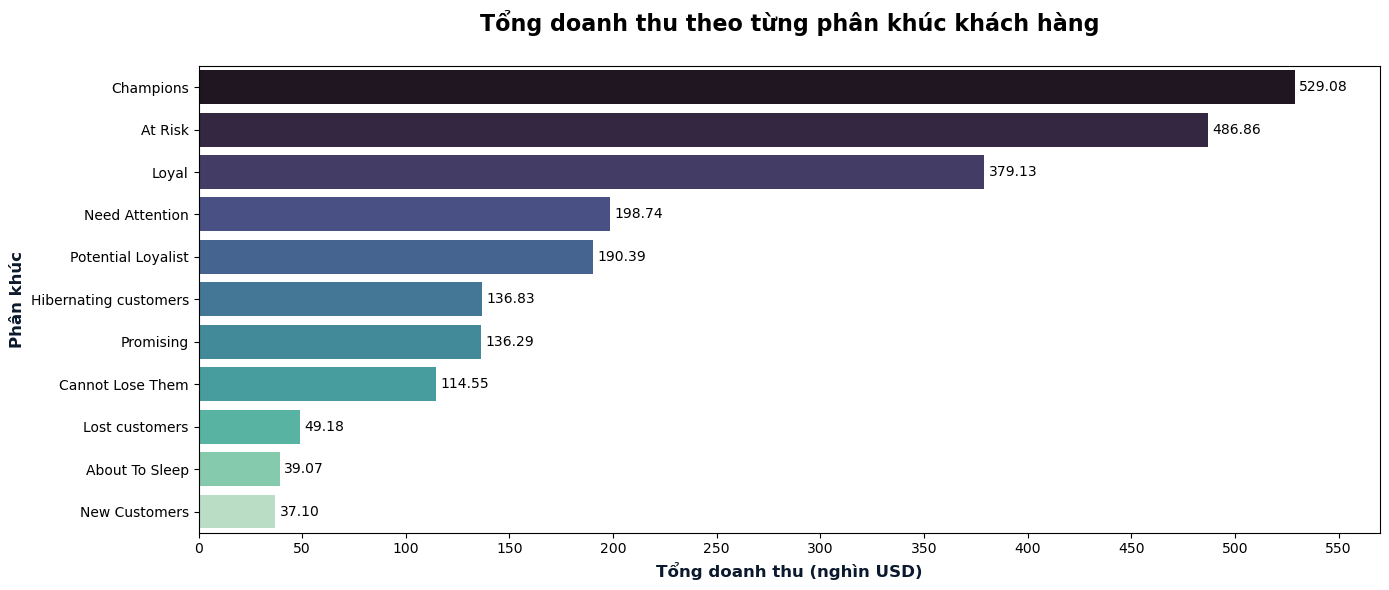

In [ ]:
# Tạo Data Frame Tổng 'Monetary_Value' theo từng 'Segment'
monetary_total = df.groupby(by= 'Segment')['Monetary_Value'].sum().reset_index(name='Total in thousand dollars')
monetary_total['Total in thousand dollars'] = monetary_total['Total in thousand dollars'] / 1000 
# Sắp xếp lại dữ liệu theo tổng 'Monetary_Value' để tiện hiểu thị trong chart
monetary_total.sort_values(by='Total in thousand dollars', ascending=False, inplace=True) 

# Vẽ chart barplot tính tổng doanh thu
plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data= monetary_total,
    y= 'Segment',
    x= 'Total in thousand dollars',
    palette= 'mako'
)

plt.title(label='Tổng doanh thu theo từng phân khúc khách hàng\n', fontsize=16, weight='bold', color= '#000000')
plt.xlabel(xlabel= 'Tổng doanh thu (nghìn USD)', fontsize= 12, weight= 'bold', color= '#0B192C')
plt.ylabel(ylabel= 'Phân khúc', fontsize= 12, weight= 'bold', color= '#0B192C')
plt.xticks(ticks= range(0, 551, 50))
plt.xlim(0, 570)

for cont in ax.containers:
    plt.bar_label(cont, padding=3, fmt= '%.2f')

plt.tight_layout()
plt.show()

## 2. Trung bình thu theo từng phân khúc khách hàng

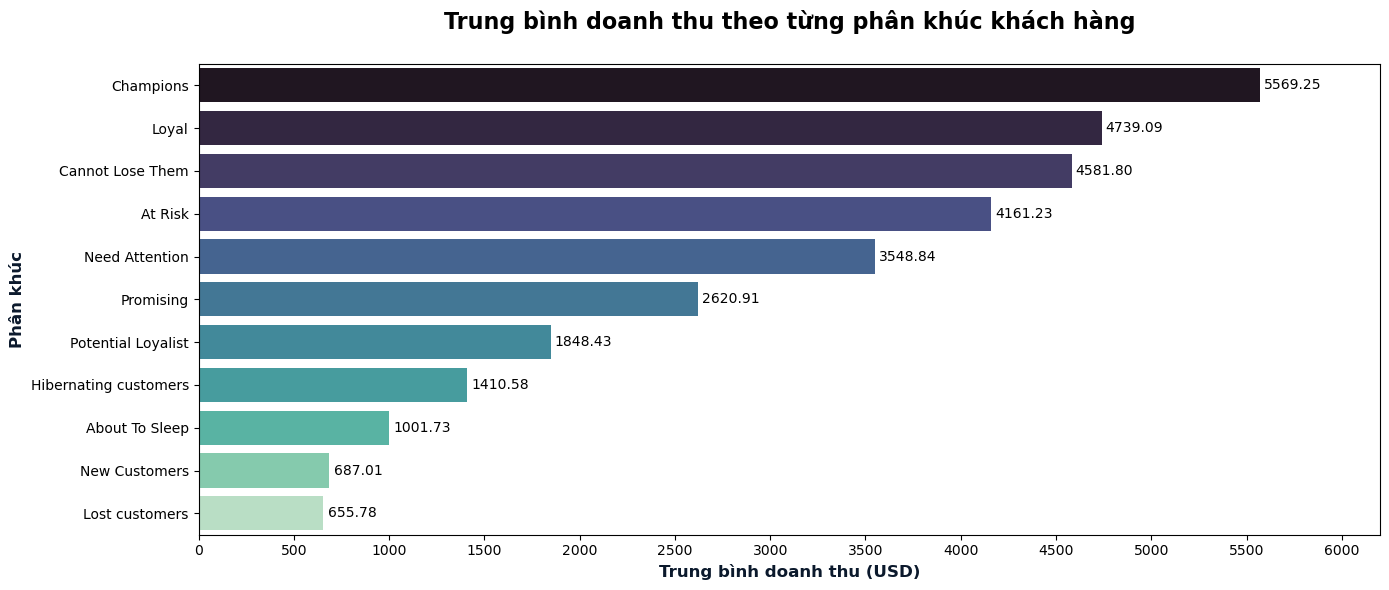

In [8]:
# vẽ  chart barplot tính trung bình doanh thu
plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data= monetary,
    y= 'Segment',
    x= 'Monetary_Value',
    palette= 'mako'
)

plt.title(label='Trung bình doanh thu theo từng phân khúc khách hàng\n', fontsize=16, weight='bold', color= '#000000')
plt.xlabel(xlabel= 'Trung bình doanh thu (USD)', fontsize= 12, weight= 'bold', color= '#0B192C')
plt.ylabel(ylabel= 'Phân khúc', fontsize= 12, weight= 'bold', color= '#0B192C')
plt.xticks(ticks= range(0, 6001, 500))
plt.xlim(0, 6200)

for cont in ax.containers:
    plt.bar_label(cont, padding=3, fmt= '%.2f')

plt.tight_layout()
plt.show()

## 3. Phân bổ khách hàng theo từng phân khúc

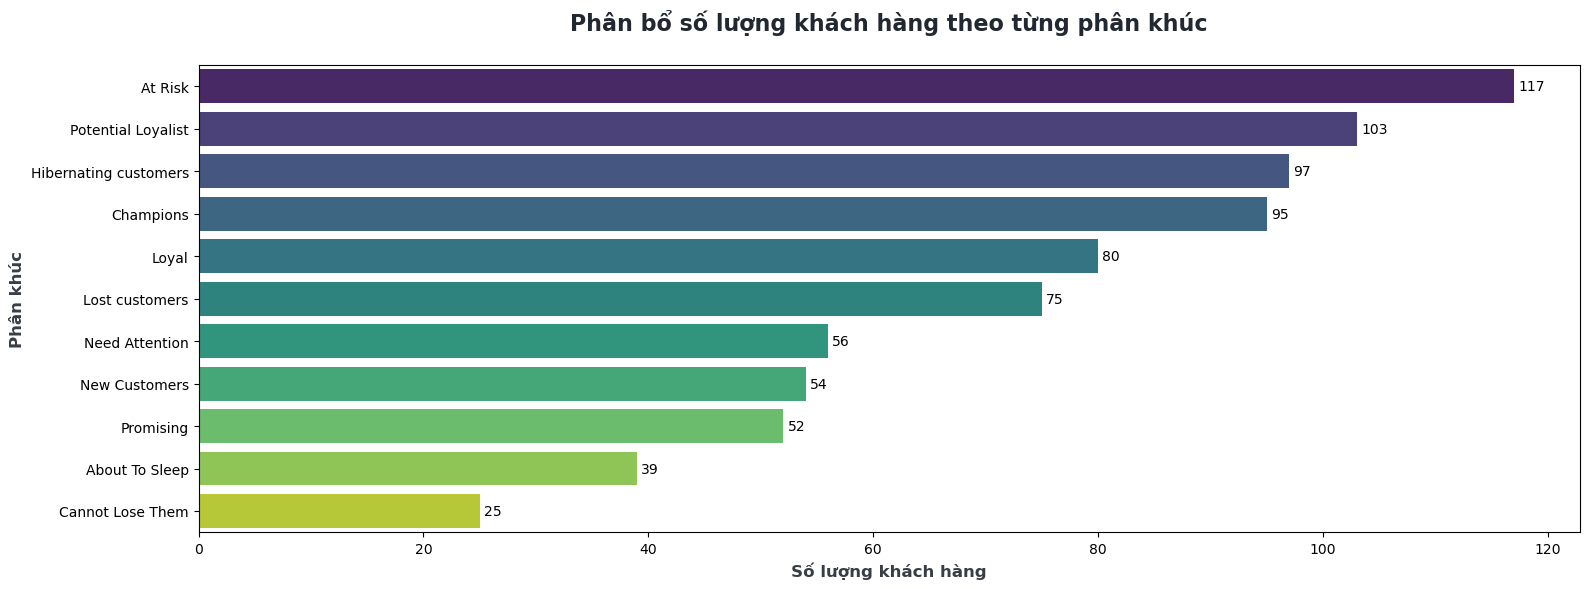

In [9]:
# Tạo Data Frame đếm từng 'Segment'
segment_counts = df.groupby(by='Segment')['Segment'].count().reset_index(name='Count')
segment_counts.sort_values(by= 'Count', ascending=False, inplace= True)

# Vẽ chart barplot kiểm tra sự phân bổ của khách hàng
plt.figure(figsize=(16,6)) 

ax = sns.barplot(
    data= segment_counts, 
    y= 'Segment', 
    x= 'Count', 
    palette= 'viridis'
)

plt.title(label= 'Phân bổ số lượng khách hàng theo từng phân khúc\n', fontsize= 16, weight= 'bold', color= '#222831')
plt.xlabel(xlabel= 'Số lượng khách hàng', fontsize= 12, weight= 'bold', color= '#393E46')
plt.ylabel(ylabel= 'Phân khúc', fontsize= 12, weight= 'bold', color= '#393E46')

for cont in ax.containers:
    plt.bar_label(cont, padding= 3)

plt.tight_layout()
plt.show()

# III. Insight & Đề xuất hành động

Sau khi phân tích biểu đồ phân bổ khách hàng dựa trên mô hình RFM, chúng ta rút ra 3 nhận định cốt lõi sau:

## 1. Nhóm "Nòng cốt" (Champions & Loyal Customers)
* **Kết luận:** Theo biểu đồ phân bổ, nhóm Champions và Loyal chỉ chiếm khoảng **19%** tổng lượng khách hàng nhưng đóng góp tới **40%** tổng doanh thu.
* **Đặc điểm:** Đây là tệp khách hàng mang lại giá trị cao nhất cho doanh nghiệp.
* **Hành động:** Đây là nguồn sống của doanh nghiệp. Cần ưu tiên các chương trình khách hàng thân thiết (Loyalty Program) và các dịch vụ chăm sóc đặc biệt để đảm bảo họ không rời đi.

## 2. "Tiền đang rơi" ở nhóm Cannot Lose Them
* **Kết luận:** Nhóm này từng chi tiêu rất lớn (trung bình **~$4,739**, ngang ngửa nhóm Champions) nhưng hiện đã hơn **500 ngày** chưa quay lại giao dịch.
* **Đặc điểm:** Doanh nghiệp đang có nguy cơ mất đi những "đại gia" từng gắn bó rất mật thiết.
* **Hành động:** Cần triển khai ngay chiến dịch lôi kéo quay lại (Win-back campaign). Việc kích hoạt lại nhóm này mang lại hiệu quả cao vì chi phí giữ chân khách cũ rẻ hơn nhiều so với việc tìm kiếm khách hàng mới.

## 3. Hệ thống đang bị "nguội lạnh" (At Risk & Hibernating)
* **Kết luận:** Hai nhóm At Risk và Hibernating đang chiếm số lượng đông đảo nhất trên biểu đồ với tổng cộng **221 khách hàng**.
* **Đặc điểm:** Đây là dấu hiệu cảnh báo hệ thống đang có nhiều khách hàng dần quên đi thương hiệu.
* **Hành động:** Nếu không có biện pháp kích hoạt lại bằng Email Marketing hoặc các chương trình khuyến mãi, phần lớn nhóm này sẽ sớm chuyển sang trạng thái **Lost**, gây sụt giảm doanh thu nghiêm trọng trong dài hạn